In [1]:
import pickle

with open("score_distributions.pkl", "rb") as f:
    data = pickle.load(f)

print(type(data))

if isinstance(data, dict):
    print(data.keys())
    for k, v in data.items():
        print(k, type(v), len(v))
else:
    print(data)

<class 'dict'>
dict_keys(['junk', 'kept', 'all'])
junk <class 'dict'> 10
kept <class 'dict'> 10
all <class 'dict'> 10


In [2]:
for group, values in data.items():
    print(f"\n=== {group} ===")
    for k, v in values.items():
        print(k, type(v), v if not hasattr(v, "__len__") else f"len={len(v)}")


=== junk ===
0 <class 'dict'> len=50
1 <class 'dict'> len=57
2 <class 'dict'> len=46
3 <class 'dict'> len=51
4 <class 'dict'> len=31
5 <class 'dict'> len=47
6 <class 'dict'> len=51
7 <class 'dict'> len=11
8 <class 'dict'> len=50
9 <class 'dict'> len=51

=== kept ===
0 <class 'dict'> len=50
1 <class 'dict'> len=63
2 <class 'dict'> len=50
3 <class 'dict'> len=51
4 <class 'dict'> len=31
5 <class 'dict'> len=51
6 <class 'dict'> len=51
7 <class 'dict'> len=11
8 <class 'dict'> len=50
9 <class 'dict'> len=50

=== all ===
0 <class 'dict'> len=50
1 <class 'dict'> len=63
2 <class 'dict'> len=50
3 <class 'dict'> len=51
4 <class 'dict'> len=31
5 <class 'dict'> len=51
6 <class 'dict'> len=51
7 <class 'dict'> len=11
8 <class 'dict'> len=50
9 <class 'dict'> len=51


In [3]:
print(data["junk"][0].keys())

first_key = next(iter(data["junk"][0]))
print(first_key)
print(data["junk"][0][first_key])
print(type(data["junk"][0][first_key]))

dict_keys([50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100])
50
434076
<class 'int'>


| Index | Meaning               |
| ----- | --------------------- |
| 0     | WDS score             |
| 1     | lang_score            |
| 2     | url_score             |
| 3     | punctuation_score     |
| 4     | singular_chars_score  |
| 5     | numbers_score         |
| 6     | repeated_score        |
| 7     | informativeness_score |
| 8     | n_long_segment_score  |
| 9     | great_segment_score   |


In [4]:
import plotly.io as pio

pio.renderers.default = "browser"


In [6]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

titles = [
    'WDS score',
    'lang_score',
    'url_score',
    'punctuation_score',
    'singular_chars_score',
    'numbers_score',
    'repeated_score',
    'informativeness_score',
    'n_long_segment_score',
    'great_segment_score'
]


In [7]:
import plotly.graph_objects as go

reg = 0

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=list(data["junk"][reg].keys()),
        y=list(data["junk"][reg].values()),
        mode="lines",
        name="Junk"
    )
)

fig.add_trace(
    go.Scatter(
        x=list(data["kept"][reg].keys()),
        y=list(data["kept"][reg].values()),
        mode="lines",
        name="Kept"
    )
)

fig.update_layout(
    title=f"Register {reg} score distribution",
    xaxis_title="Score",
    yaxis_title="Number of documents",
    template="plotly_white"
)

fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

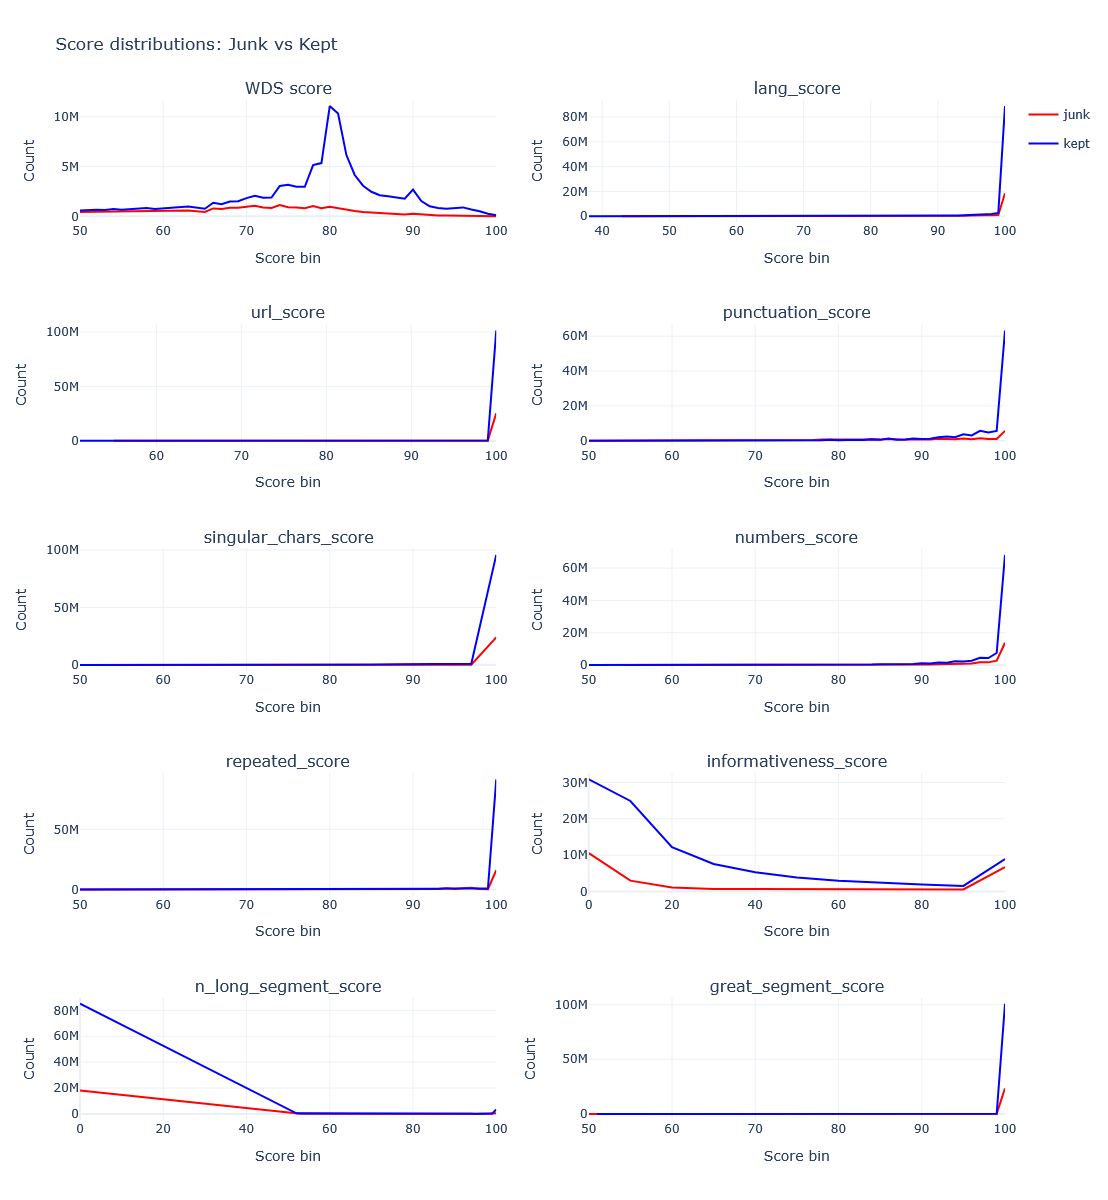

In [13]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

titles = [
    'WDS score',
    'lang_score',
    'url_score',
    'punctuation_score',
    'singular_chars_score',
    'numbers_score',
    'repeated_score',
    'informativeness_score',
    'n_long_segment_score',
    'great_segment_score'
]

fig = make_subplots(
    rows=5,
    cols=2,
    subplot_titles=titles
)

for i, title in enumerate(titles):
    row = i // 2 + 1
    col = i % 2 + 1

    for dataset, color in [("junk", "red"), ("kept", "blue")]:
        x = list(data[dataset][i].keys())
        y = list(data[dataset][i].values())

        fig.add_trace(
            go.Scatter(
                x=x,
                y=y,
                mode="lines",
                name=dataset,
                legendgroup=dataset,
                showlegend=(i == 0),
                line=dict(color=color)
            ),
            row=row,
            col=col
        )

fig.update_layout(
    height=1200,
    width=1000,
    title="Score distributions: Junk vs Kept",
    template="plotly_white"
)

fig.update_xaxes(title_text="Score bin")
fig.update_yaxes(title_text="Count")

fig.show()

In [15]:
fig.write_html("Junk_vs_Kept_count.html")

In [8]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

titles = [
    'WDS score',
    'lang_score',
    'url_score',
    'punctuation_score',
    'singular_chars_score',
    'numbers_score',
    'repeated_score',
    'informativeness_score',
    'n_long_segment_score',
    'great_segment_score'
]

fig = make_subplots(
    rows=5,
    cols=2,
    subplot_titles=titles
)

for i, title in enumerate(titles):
    row = i // 2 + 1
    col = i % 2 + 1

    for dataset, color in [("junk", "red"), ("all", "black")]:
        x = list(data[dataset][i].keys())
        y = list(data[dataset][i].values())

        # normalize
        total = sum(y)
        y = [v / total for v in y]

        fig.add_trace(
            go.Scatter(
                x=x,
                y=y,
                mode="lines",
                name=dataset,
                legendgroup=dataset,
                showlegend=(i == 0),
                line=dict(color=color)
            ),
            row=row,
            col=col
        )

fig.update_layout(
    height=1200,
    width=1000,
    title="Score distributions: Junk vs All",
    template="plotly_white"
)

fig.update_xaxes(title_text="Score bin")
fig.update_yaxes(title_text="Proportion")

fig.show()

In [19]:
fig.write_html("Junk_vs_all_propotion.html")

# Each seprately

Shows the distribution of scores within each dataset (junk and all are each normalised separately).

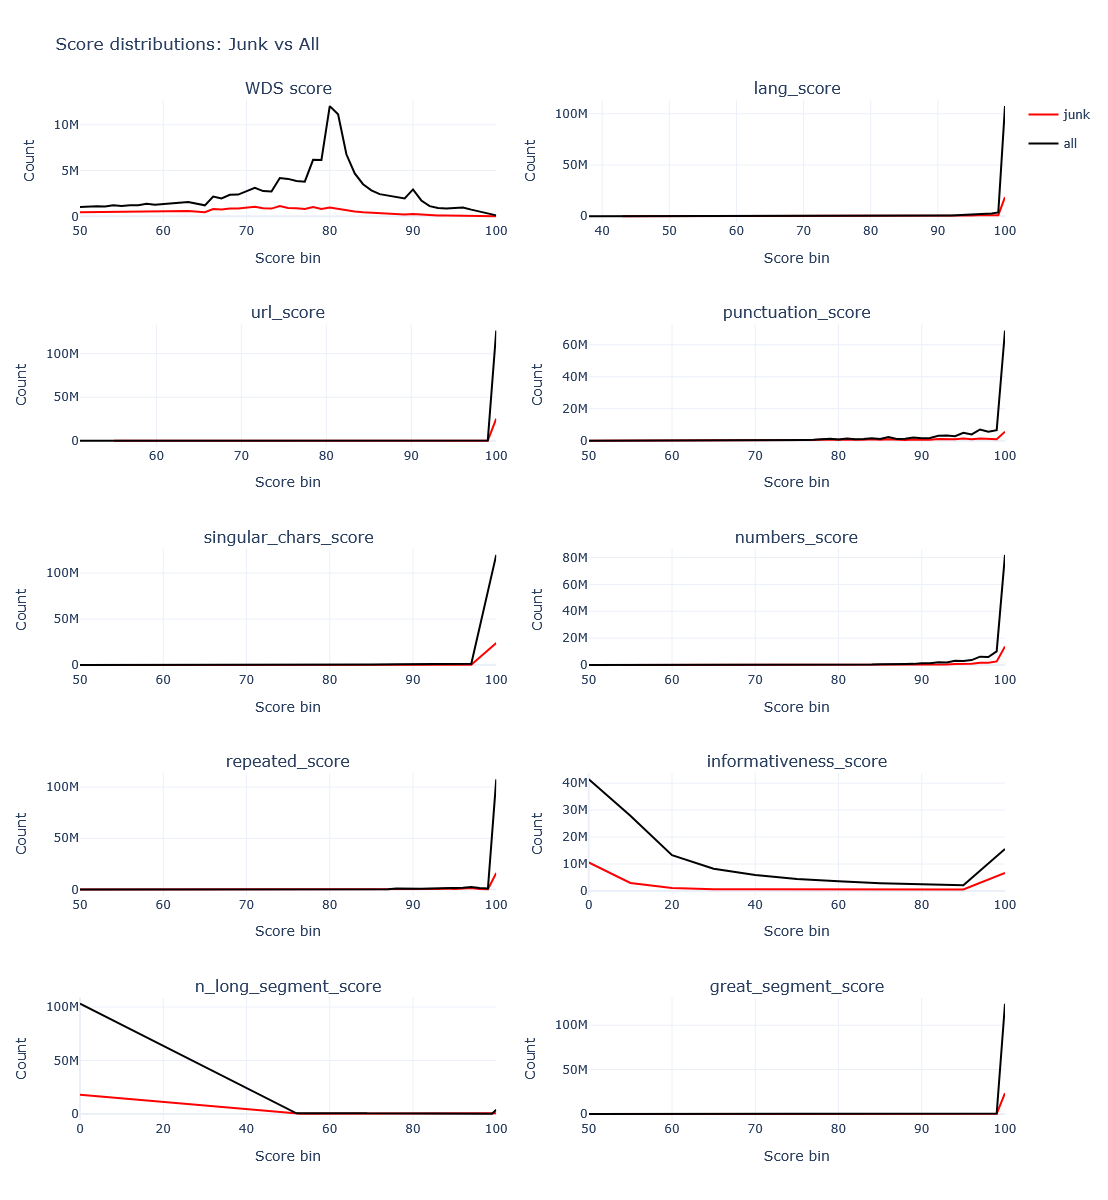

In [20]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

titles = [
    'WDS score',
    'lang_score',
    'url_score',
    'punctuation_score',
    'singular_chars_score',
    'numbers_score',
    'repeated_score',
    'informativeness_score',
    'n_long_segment_score',
    'great_segment_score'
]

fig = make_subplots(
    rows=5,
    cols=2,
    subplot_titles=titles
)

for i, title in enumerate(titles):
    row = i // 2 + 1
    col = i % 2 + 1

    for dataset, color in [("junk", "red"), ("all", "black")]:
        x = list(data[dataset][i].keys())
        y = list(data[dataset][i].values())

        fig.add_trace(
            go.Scatter(
                x=x,
                y=y,
                mode="lines",
                name=dataset,
                legendgroup=dataset,
                showlegend=(i == 0),
                line=dict(color=color)
            ),
            row=row,
            col=col
        )

fig.update_layout(
    height=1200,
    width=1000,
    title="Score distributions: Junk vs All",
    template="plotly_white"
)

fig.update_xaxes(title_text="Score bin")
fig.update_yaxes(title_text="Count")

fig.show()

In [21]:
fig.write_html("Junk_vs_all_count.html")

# Fraction

# Figure Y

Shows the distribution of scores as a fraction of the entire dataset (both junk and all are normalised by the total number of samples in "all").

In [6]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

titles = [
    'WDS score',
    'lang_score',
    'url_score',
    'punctuation_score',
    'singular_chars_score',
    'numbers_score',
    'repeated_score',
    'informativeness_score',
    'n_long_segment_score',
    'great_segment_score'
]

In [7]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

titles = [
    'WDS score',
    'lang_score',
    'url_score',
    'punctuation_score',
    'singular_chars_score',
    'numbers_score',
    'repeated_score',
    'informativeness_score',
    'n_long_segment_score',
    'great_segment_score'
]

fig = make_subplots(
    rows=5,
    cols=2,
    subplot_titles=titles
)

for i, title in enumerate(titles):
    row = i // 2 + 1
    col = i % 2 + 1

    # Total number of samples in the "all" dataset for this score
    all_total = sum(data["all"][i].values())

    for dataset, color in [("junk", "red"), ("all", "black")]:
        x = list(data[dataset][i].keys())
        y = list(data[dataset][i].values())

        # Normalize by the total number of samples in "all"
        y = [v / all_total for v in y]

        fig.add_trace(
            go.Scatter(
                x=x,
                y=y,
                mode="lines",
                name=dataset,
                legendgroup=dataset,
                showlegend=(i == 0),
                line=dict(color=color)
            ),
            row=row,
            col=col
        )

fig.update_layout(
    height=1200,
    width=1000,
    title="Score distributions: Junk vs All (% of all data) based on Score",
    template="plotly_white"
)

fig.update_xaxes(title_text="Score bin")
fig.update_yaxes(title_text="Fraction of all samples")

fig.show()

In [26]:
fig.update_layout(
    template="plotly_white",
    width=1800,
    height=2200,
    font=dict(size=18),
    title_font=dict(size=24),
)

fig.write_image(
    "Figure_Y_full.png",
    scale=2
)

In [38]:
import plotly.graph_objects as go

# Select WDS score
i = titles.index("WDS score")

all_total = sum(data["all"][i].values())

fig = go.Figure()

for dataset, color in [("junk", "red"), ("all", "black")]:
    x = sorted(data[dataset][i].keys())
    y = [data[dataset][i][b] / all_total for b in x]

    fig.add_trace(
        go.Scatter(
            x=x,
            y=y,
            mode="lines",
            name=dataset.capitalize(),
            line=dict(color=color, width=2),
        )
    )

fig.update_layout(
    template="plotly_white",
    width=700,
    height=500,
    font=dict(size=16),
    margin=dict(l=60, r=20, t=20, b=60),
)

fig.update_xaxes(
    title="WDS score bin",
    showgrid=True,
)

fig.update_yaxes(
    title="Fraction of all samples",
    showgrid=True,
)

fig.show()

# Save for paper
#fig.write_image("wds_score_distribution.png", width=1400, height=1000, scale=2)

In [18]:
import kaleido
fig.write_image("wds_score_distribution.png", scale=3)

In [23]:
fig.write_html("Junk_vs_all_fraction.html")

In [41]:
#scaling between 5 to 10

import plotly.graph_objects as go

# Select WDS score
i = titles.index("WDS score")

all_total = sum(data["all"][i].values())

fig = go.Figure()

for dataset, color in [("junk", "red"), ("all", "black")]:
    x = np.array(sorted(data[dataset][i].keys()), dtype=float)
    y = [data[dataset][i][b] / all_total for b in x]

    fig.add_trace(
        go.Scatter(
            x=x / 10,   # display WDS score as 5.0-10.0 instead of 50-100
            y=y,
            mode="lines",
            name="Low-quality" if dataset == "junk" else dataset.capitalize(),
            line=dict(color=color, width=2),
        )
    )

fig.update_xaxes(
    title="WDS score",
    range=[5, 10],
    dtick=1,
    showgrid=True,
)

fig.update_yaxes(
    title="Fraction of all samples",
    showgrid=True,
)

fig.update_layout(
    template="plotly_white",
    width=700,
    height=500,
    font=dict(size=16),
    margin=dict(l=60, r=20, t=20, b=60),
)

fig.show()

In [42]:
import kaleido
fig.write_image("wds_score_distribution_scaled.png", scale=3)

In [19]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 14,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "legend.frameon": True,
    "legend.framealpha": 1.0,
    "legend.borderpad": 0.5,
    "legend.labelspacing": 0.5,
    "legend.handlelength": 2.0,
    "legend.handletextpad": 0.8,
    "axes.linewidth": 1.2,
    "lines.linewidth": 2,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
})

plt.rcParams["figure.dpi"] = 300
plt.rcParams["savefig.dpi"] = 300

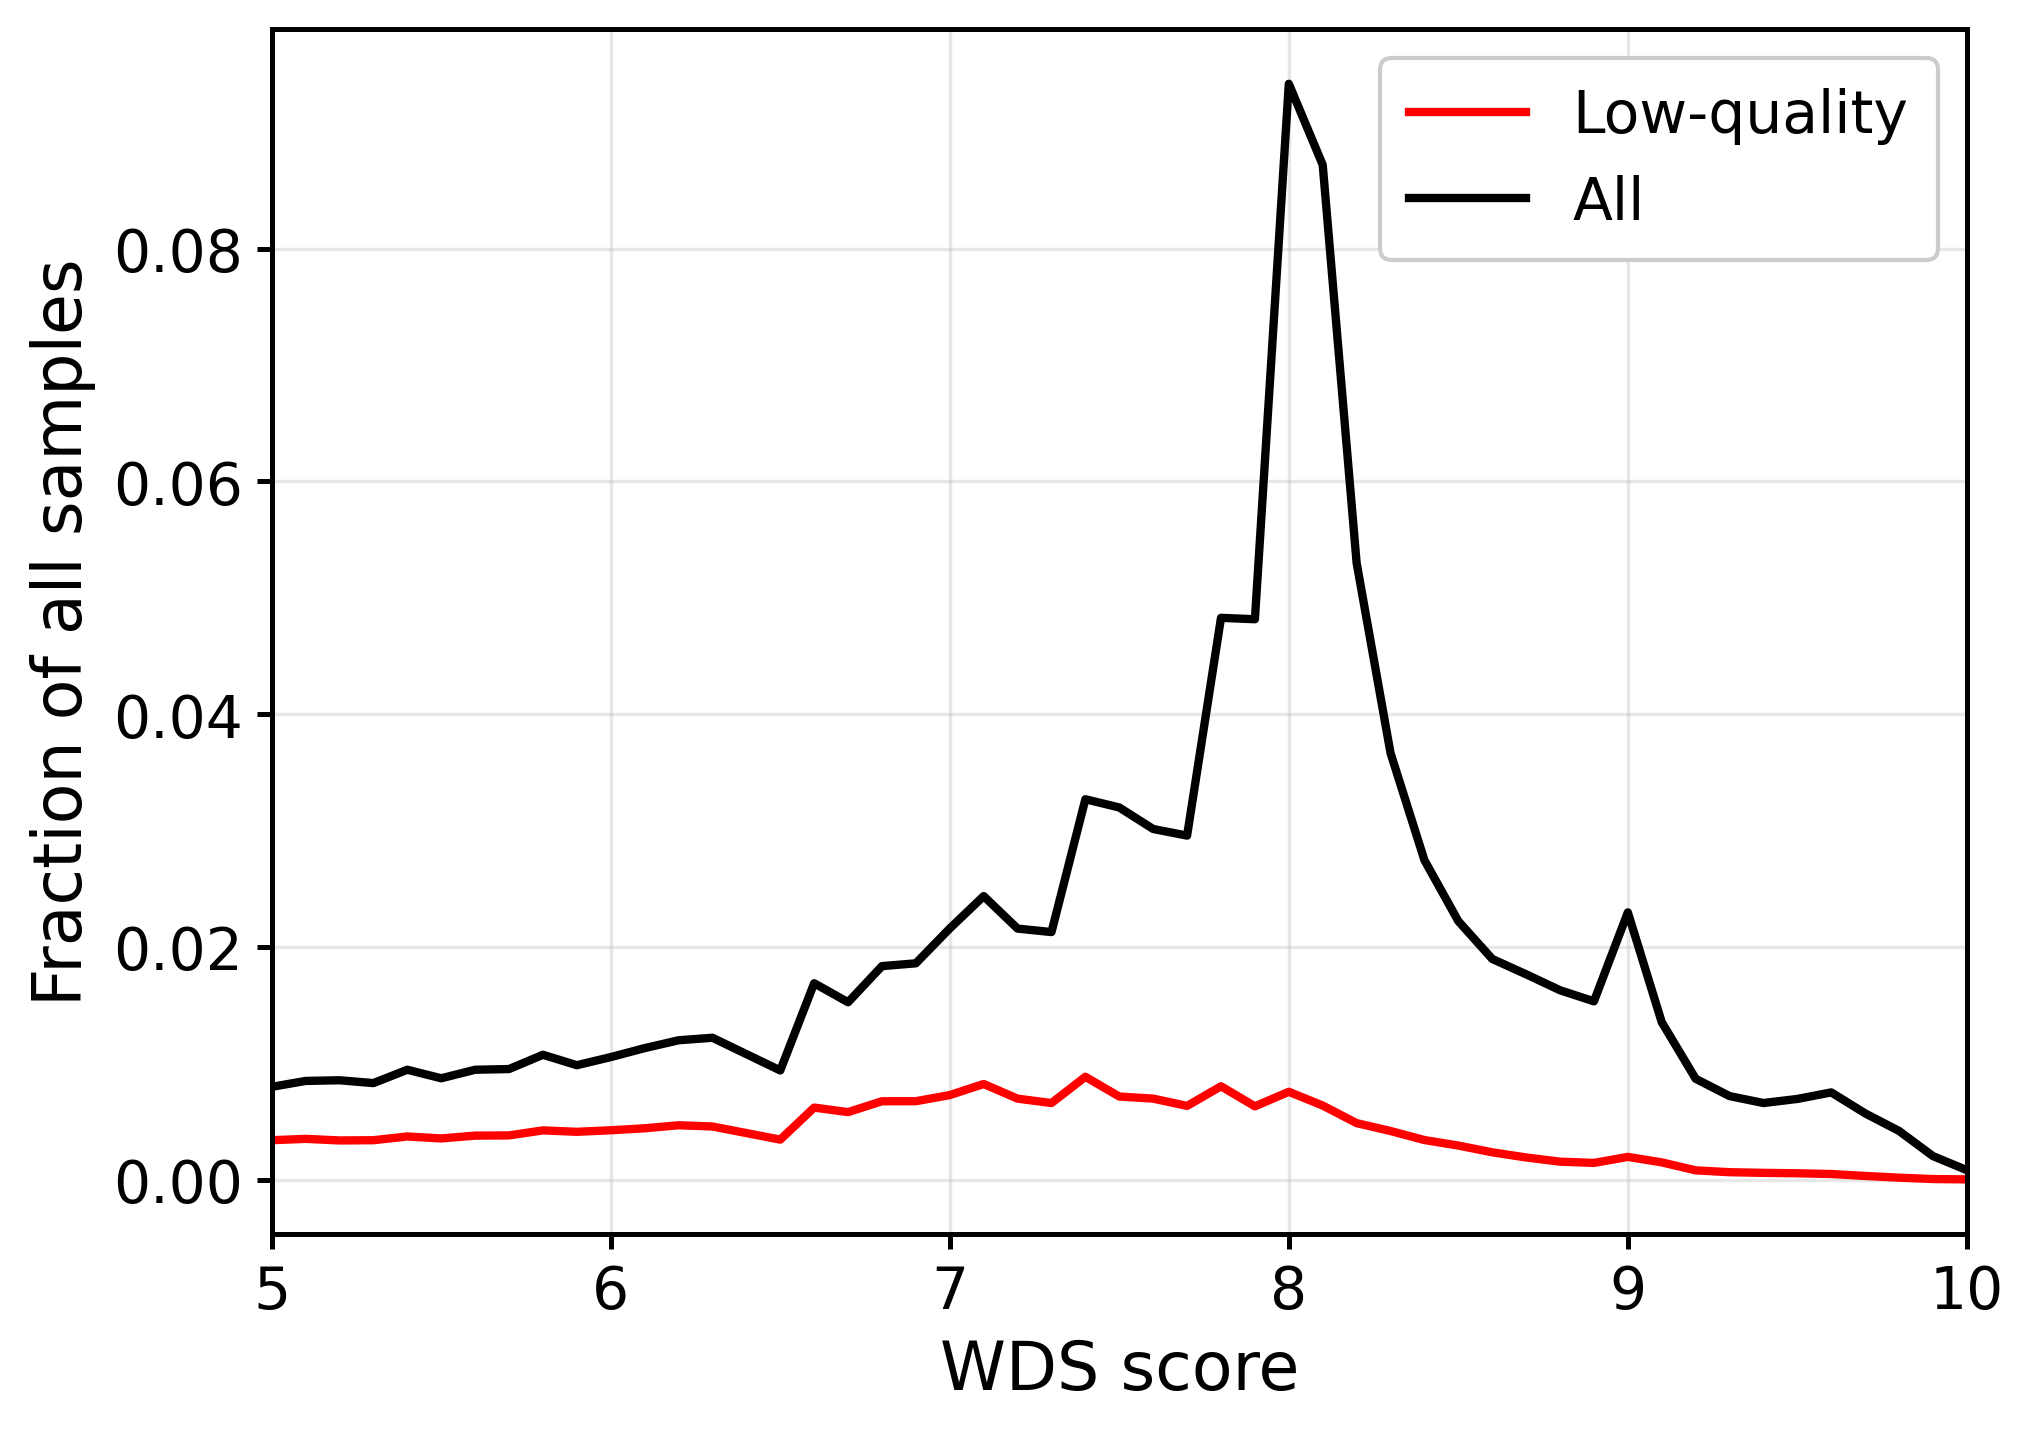

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# Select WDS score
i = titles.index("WDS score")

all_total = sum(data["all"][i].values())

fig, ax = plt.subplots(figsize=(7, 5))

for dataset, color in [("junk", "red"), ("all", "black")]:
    x = np.array(sorted(data[dataset][i].keys()), dtype=float)
    y = [data[dataset][i][b] / all_total for b in x]

    ax.plot(
        x / 10,  # display WDS score as 5.0–10.0
        y,
        color=color,
        label="Low-quality" if dataset == "junk" else dataset.capitalize(),
    )

ax.set_xlim(5, 10)
ax.set_xticks(np.arange(5, 11, 1))

ax.set_xlabel("WDS score")
ax.set_ylabel("Fraction of all samples")

ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()
fig.savefig("score_distribution_2.png", bbox_inches="tight")

plt.show()

Suppose you have:

1,000 total samples
100 junk samples

And for one score bin:

50 total samples are in that bin.
20 junk samples are in that bin.
Previous code (your original)

You divided by the total within each dataset.

For the junk curve:

20 / 100 = 0.20

So the plot says:

20% of all junk samples fall into this score bin.

For the all curve:

50 / 1000 = 0.05

So it says:

5% of all samples fall into this score bin.

Notice the two curves are using different denominators:

Junk → divide by 100
All → divide by 1000

So you're comparing shapes, not actual amounts.

New code (fraction)

Now you divide both by the total number of all samples (1000).

For the junk curve:
20 / 1000 = 0.02

For the all curve:

50 / 1000 = 0.05

Now both curves use the same denominator (1000).

This means you can directly compare them.

The red value (0.02) literally means:
2% of the entire dataset are junk samples in this score bin.

The black value (0.05) means:

5% of the entire dataset are samples (junk + non-junk) in this score bin.

In one sentence
Old code: "Where do junk samples occur?" (distribution within junk)
New code: "How much of the entire dataset is junk at each score?" (distribution relative to all data)

# maybe in paper

Figure Y compares the WDS score distribution of the complete Persian HPLT3 corpus with that of documents classified as junk. Since both histograms are normalised by the total number of documents, the junk distribution represents a subset of the overall score distribution. While junk documents occur throughout the WDS score range, their distribution does not mirror the sharp concentration of the corpus around WDS ≈80, suggesting that the prevalence of junk varies with WDS score. However, the substantial overlap between the two distributions indicates that WDS score alone is insufficient to distinguish junk from non-junk documents.

# Other plots

# Figure X

# Figure 2 (The important one)

This is the figure reviewers will probably look at first.

It plots

P(junk∣score)=
#documents in score bin
#junk in score bin
	​


In [22]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

fig = make_subplots(
    rows=5,
    cols=2,
    subplot_titles=titles
)

for i, title in enumerate(titles):

    row = i // 2 + 1
    col = i % 2 + 1

    bins = sorted(data["all"][i].keys())

    x = []
    y = []

    for b in bins:

        all_count = data["all"][i][b]
        junk_count = data["junk"][i].get(b, 0)

        if all_count > 0:
            x.append(b)
            y.append(junk_count / all_count)

    fig.add_trace(
        go.Scatter(
            x=x,
            y=y,
            mode="lines+markers",
            line=dict(width=2),
            name="Junk proportion",
            showlegend=False,
        ),
        row=row,
        col=col
    )

fig.update_layout(
    template="plotly_white",
    height=1200,
    width=1000,
    title="Fraction of documents classified as junk by scores"
)

fig.update_xaxes(title_text="Score bin")
fig.update_yaxes(title_text="P(junk | score)")

fig.show()

In [ ]:
import kaleido
fig.write_image("Figure_X_full.png", scale=3)

In [23]:
fig.update_layout(
    template="plotly_white",
    width=1800,
    height=2200,
    font=dict(size=18),
    title_font=dict(size=24),
)

fig.write_image(
    "Figure_X_full.png",
    scale=2
)

In [35]:
import plotly.graph_objects as go

# Choose which metric to plot
i = 0  # e.g. first WDS score

bins = sorted(data["all"][i].keys())

x = []
y = []

for b in bins:
    all_count = data["all"][i][b]
    junk_count = data["junk"][i].get(b, 0)

    if all_count > 0:
        x.append(b)
        y.append(junk_count / all_count)

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=x,
        y=y,
        mode="lines+markers",
        line=dict(width=2, color="blue"),
        marker=dict(size=6),
    )
)

fig.update_layout(
    template="plotly_white",
    width=700,
    height=500,
    font=dict(size=16),
    margin=dict(l=60, r=20, t=20, b=60),
)

fig.update_xaxes(
    title="Score bin",
    showgrid=True,
    zeroline=False,
)

fig.update_yaxes(
    title="P(junk | score)",
    showgrid=True,
    zeroline=False,
)

fig.show()

In [20]:
import kaleido
fig.write_image("wds_score_vs_score_bin.png", scale=3)

The curve answers the following question:

Among all documents with WDS score x, what fraction were classified as junk?

or equivalently,

How prevalent is junk within each WDS score bin?

In [ ]:
fig.write_html("beingJNK_vs_score.html")

Figure X shows the prevalence of documents classified as junk as a function of WDS score. A clear inverse relationship is observed between WDS score and junk prevalence. Approximately 42% of documents with a WDS score of 50 are classified as junk, whereas this proportion decreases to below 5% for documents with WDS scores above 95. The decline is not uniform across the score range, with the steepest reduction occurring between WDS scores of approximately 74 and 80. These results indicate that the WDS score is strongly associated with document quality, although a small proportion of junk documents persists even among the highest-scoring documents, motivating the use of a dedicated junk classifier in addition to WDS-based filtering.

In [34]:
proportion = {}

for b in sorted(data["all"][0].keys()):
    all_count = data["all"][0][b]
    junk_count = data["junk"][0].get(b, 0)

    proportion[b] = junk_count / all_count

In [35]:
print(proportion[80])

0.08021094850881928


Your current figure answers

Where are junk documents?

Figure 2 answers

Given a score, how likely is a document to be junk?

# Figure 3 (Odds ratio)

This shows whether each score is better or worse than average.

First compute the global junk rate

In [11]:
total_junk = sum(data["junk"][0].values())
total_all = sum(data["all"][0].values())

global_rate = total_junk / total_all

In [12]:
ratio = (junk_count/all_count) / global_rate

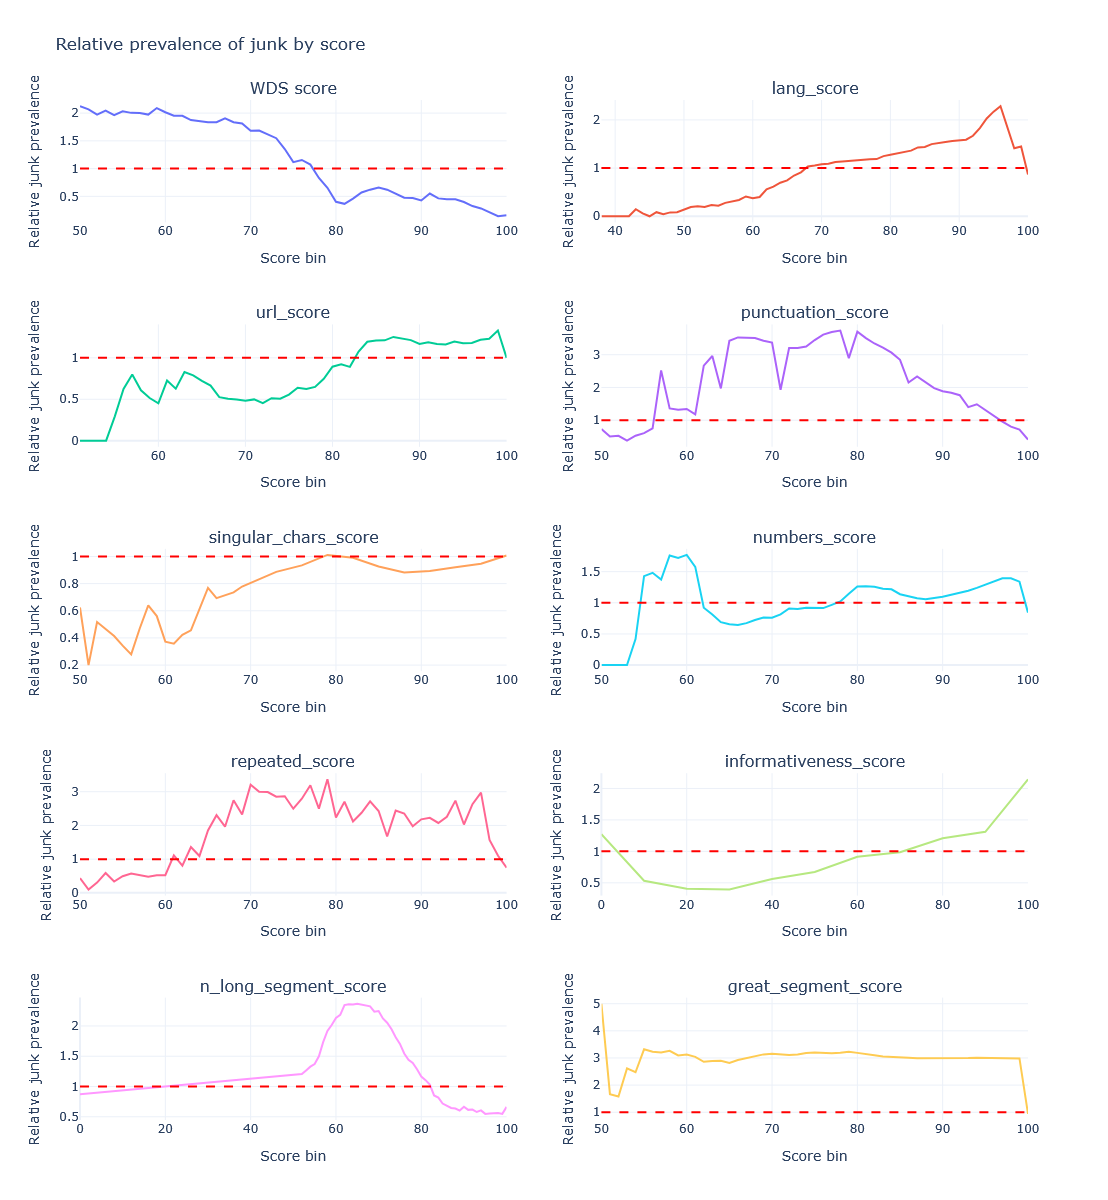

In [31]:
fig = make_subplots(
    rows=5,
    cols=2,
    subplot_titles=titles
)

for i, title in enumerate(titles):

    row = i // 2 + 1
    col = i % 2 + 1

    total_junk = sum(data["junk"][i].values())
    total_all = sum(data["all"][i].values())

    global_rate = total_junk / total_all

    x = []
    y = []

    for b in sorted(data["all"][i].keys()):

        all_count = data["all"][i][b]
        junk_count = data["junk"][i].get(b,0)

        if all_count > 0:

            x.append(b)
            y.append((junk_count/all_count)/global_rate)

    fig.add_trace(
        go.Scatter(
            x=x,
            y=y,
            mode="lines",
            showlegend=False
        ),
        row=row,
        col=col
    )

    fig.add_hline(
        y=1,
        line_dash="dash",
        line_color="red",
        row=row,
        col=col
    )

fig.update_layout(
    template="plotly_white",
    height=1200,
    width=1000,
    title="Relative prevalence of junk by score"
)

fig.update_xaxes(title_text="Score bin")
fig.update_yaxes(title_text="Relative junk prevalence")

fig.show()

In [27]:
import numpy as np
p = junk_count / all_count

se = np.sqrt(p * (1 - p) / all_count)

lower = p - 1.96 * se
upper = p + 1.96 * se

# Conclusion writing for Figure X and Y

Figure Y presents the marginal distribution of WDS scores for the entire corpus and for documents classified as junk. Because the corpus itself is concentrated around WDS≈80, the majority of junk documents also fall within this range in absolute terms. However, this distribution does not account for the underlying number of documents at each score. Figure X therefore reports the prevalence of junk within each WDS score bin. After normalising by the total number of documents in each bin, a clear inverse relationship emerges: the proportion of documents classified as junk decreases from approximately 42% at WDS=50 to below 5% at WDS>95.

# logistic Reg

In [1]:
import pickle
import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression

import plotly.graph_objects as go


# ---------------------------------------------------------
# Load
# ---------------------------------------------------------

with open("score_distributions.pkl", "rb") as f:
    data = pickle.load(f)


# ---------------------------------------------------------
# Build weighted dataset
# ---------------------------------------------------------

rows = []

bins = sorted(data["all"][0].keys())     # WDS only

for b in bins:

    all_count = data["all"][0][b]
    junk_count = data["junk"][0].get(b, 0)

    kept_count = all_count - junk_count

    if junk_count > 0:
        rows.append({
            "score": b,
            "junk": 1,
            "weight": junk_count
        })

    if kept_count > 0:
        rows.append({
            "score": b,
            "junk": 0,
            "weight": kept_count
        })


df = pd.DataFrame(rows)

print(df.head())

   score  junk  weight
0     50     1  434076
1     50     0  586707
2     51     1  448816
3     51     0  636907
4     52     1  431406


In [2]:
model = LogisticRegression(max_iter=1000)

model.fit(
    df[["score"]],
    df["junk"],
    sample_weight=df["weight"]
)

print("Coefficient:", model.coef_[0][0])
print("Intercept :", model.intercept_[0])

Coefficient: -0.06552314402962804
Intercept : 3.500901511026517


In [3]:
x = []
y = []

for b in bins:

    x.append(b)

    y.append(
        data["junk"][0].get(b, 0)
        /
        data["all"][0][b]
    )

In [4]:
xfit = np.linspace(50, 100, 500)

yfit = model.predict_proba(
    xfit.reshape(-1,1)
)[:,1]

c:\Users\alrazz\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [6]:
import plotly.io as pio

pio.renderers.default = "browser"


In [8]:
fig = go.Figure()

fig.add_trace(

    go.Scatter(

        x=x,
        y=y,

        mode="markers",

        name="Observed",

        marker=dict(size=8)

    )

)

fig.add_trace(

    go.Scatter(

        x=xfit,
        y=yfit,

        mode="lines",

        name="Logistic fit",

        line=dict(width=3)

    )

)

fig.update_layout(

    template="plotly_white",

    title="Probability of being classified as junk given the WDS score",

    xaxis_title="WDS score",

    yaxis_title="P(junk | WDS)"

)

fig.show()

In [16]:
fig = go.Figure()

# Observed prevalence
fig.add_trace(
    go.Scatter(
        x=x,
        y=y,
        mode="lines+markers",
        name="Observed prevalence",
        line=dict(width=2, color="royalblue"),
        marker=dict(size=6),
    )
)

# Logistic regression fit
fig.add_trace(
    go.Scatter(
        x=xfit,
        y=yfit,
        mode="lines",
        name="Logistic regression",
        line=dict(width=3, color="crimson"),
    )
)

fig.update_layout(
    template="plotly_white",
    width=700,
    height=500,
    font=dict(size=10),
    margin=dict(l=60, r=20, t=20, b=60),
)

fig.update_xaxes(
    title="WDS score",
    showgrid=True,
    zeroline=False,
)

fig.update_yaxes(
    title="P(junk | WDS)",
    showgrid=True,
    zeroline=False,
)

fig.show()

In [15]:
import kaleido
fig.write_image("wds_score_vs_score_bin_logistic.png", scale=3)

# Sigmoid

In [2]:
import pickle
import numpy as np
import pandas as pd

from scipy.optimize import curve_fit

import plotly.graph_objects as go
import plotly.io as pio

# ---------------------------------------------------------
# Load
# ---------------------------------------------------------

with open("score_distributions.pkl", "rb") as f:
    data = pickle.load(f)

# ---------------------------------------------------------
# Build observed prevalence
# ---------------------------------------------------------

bins = sorted(data["all"][0].keys())

x = []
y = []
weights = []

for b in bins:

    all_count = data["all"][0][b]
    junk_count = data["junk"][0].get(b, 0)

    x.append(b)
    y.append(junk_count / all_count)

    # Weight each point by the number of observations
    weights.append(all_count)

x = np.asarray(x, dtype=float)
y = np.asarray(y, dtype=float)
weights = np.asarray(weights, dtype=float)

# ---------------------------------------------------------
# Sigmoid model
# ---------------------------------------------------------

def sigmoid(x, k, x0):
    return 1.0 / (1.0 + np.exp(-k * (x - x0)))

# Initial parameter guesses
p0 = [
    0.3,           # slope
    np.median(x),  # midpoint
]

# Use inverse sqrt(weight) as sigma so larger bins matter more
sigma = 1 / np.sqrt(weights)

params, covariance = curve_fit(
    sigmoid,
    x,
    y,
    p0=p0,
    sigma=sigma,
    absolute_sigma=False,
    maxfev=10000,
)

k, x0 = params

print(f"k  = {k:.6f}")
print(f"x0 = {x0:.6f}")

# ---------------------------------------------------------
# Evaluate fitted curve
# ---------------------------------------------------------

xfit = np.linspace(min(x), max(x), 500)
yfit = sigmoid(xfit, k, x0)

# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------

pio.renderers.default = "browser"

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=x,
        y=y,
        mode="lines+markers",
        name="Observed",
        marker=dict(size=8),
    )
)

fig.add_trace(
    go.Scatter(
        x=xfit,
        y=yfit,
        mode="lines",
        name="Sigmoid fit",
        line=dict(width=3),
    )
)

fig.update_layout(
    template="plotly_white",
    title="Sigmoid fit of P(junk | WDS)",
    xaxis_title="WDS score",
    yaxis_title="P(junk | WDS)",
)

fig.show()

k  = -0.061383
x0 = 52.501814


# fit multiple

In [9]:
import pickle
import numpy as np
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score, mean_squared_error
import plotly.graph_objects as go
import plotly.io as pio

# ---------------------------------------------------------
# Load
# ---------------------------------------------------------

with open("score_distributions.pkl", "rb") as f:
    data = pickle.load(f)

# ---------------------------------------------------------
# Observed prevalence
# ---------------------------------------------------------

bins = sorted(data["all"][0].keys())

x = []
y = []
weights = []

for b in bins:

    all_count = data["all"][0][b]
    junk_count = data["junk"][0].get(b, 0)

    x.append(b)
    y.append(junk_count / all_count)
    weights.append(all_count)

x = np.asarray(x, dtype=float)
y = np.asarray(y, dtype=float)
weights = np.asarray(weights, dtype=float)

# ---------------------------------------------------------
# 4-parameter logistic (4PL)
# ---------------------------------------------------------

def four_pl(x, A, D, k, x0):
    return A + (D - A) / (1 + np.exp(-k * (x - x0)))

p0 = [
    y.min(),          # lower asymptote
    y.max(),          # upper asymptote
    -0.3,             # decreasing slope
    np.median(x),     # midpoint
]

params, _ = curve_fit(
    four_pl,
    x,
    y,
    p0=p0,
    sigma=1/np.sqrt(weights),
    maxfev=20000,
)

y_4pl = four_pl(x, *params)

# ---------------------------------------------------------
# Quadratic
# ---------------------------------------------------------

coef2 = np.polyfit(x, y, deg=2, w=np.sqrt(weights))
poly2 = np.poly1d(coef2)

y_quad = poly2(x)

# ---------------------------------------------------------
# Cubic
# ---------------------------------------------------------

coef3 = np.polyfit(x, y, deg=3, w=np.sqrt(weights))
poly3 = np.poly1d(coef3)

y_cubic = poly3(x)

# ---------------------------------------------------------
# Metrics
# ---------------------------------------------------------

models = {
    "4PL": y_4pl,
    "Quadratic": y_quad,
    "Cubic": y_cubic,
}

print("\nModel comparison")
print("-" * 50)

for name, pred in models.items():

    r2 = r2_score(y, pred)
    rmse = np.sqrt(mean_squared_error(y, pred))

    print(f"{name:10s}  R² = {r2:.4f}   RMSE = {rmse:.5f}")

# ---------------------------------------------------------
# Smooth curves
# ---------------------------------------------------------

xfit = np.linspace(x.min(), x.max(), 500)

yfit_4pl = four_pl(xfit, *params)
yfit_quad = poly2(xfit)
yfit_cubic = poly3(xfit)

# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------

pio.renderers.default = "browser"

fig = go.Figure()

# Observed prevalence
fig.add_trace(
    go.Scatter(
        x=x,
        y=y,
        mode="lines+markers",
        name="Observed",
        line=dict(color="black", width=2),
        marker=dict(size=6),
    )
)

# 4PL
fig.add_trace(
    go.Scatter(
        x=xfit,
        y=yfit_4pl,
        mode="lines",
        name="4PL sigmoid",
        line=dict(width=3),
    )
)

# Quadratic
fig.add_trace(
    go.Scatter(
        x=xfit,
        y=yfit_quad,
        mode="lines",
        name="Quadratic",
    )
)

# Cubic
fig.add_trace(
    go.Scatter(
        x=xfit,
        y=yfit_cubic,
        mode="lines",
        name="Cubic",
    )
)

fig.update_layout(
    template="plotly_white",
    width=800,
    height=550,
    title="Comparison of fitted models",
    xaxis_title="WDS score",
    yaxis_title="P(junk | WDS)",
)

fig.show()


Model comparison
--------------------------------------------------
4PL         R² = 0.9738   RMSE = 0.02305
Quadratic   R² = 0.8618   RMSE = 0.05291
Cubic       R² = 0.9007   RMSE = 0.04485


# with weighted metrics

In [8]:
#weighted metrics
import pickle
import numpy as np
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score, mean_squared_error
import plotly.graph_objects as go
import plotly.io as pio

# ---------------------------------------------------------
# Load
# ---------------------------------------------------------

with open("score_distributions.pkl", "rb") as f:
    data = pickle.load(f)

# ---------------------------------------------------------
# Observed prevalence
# ---------------------------------------------------------

bins = sorted(data["all"][0].keys())

x = []
y = []
weights = []

for b in bins:

    all_count = data["all"][0][b]
    junk_count = data["junk"][0].get(b, 0)

    x.append(b)
    y.append(junk_count / all_count)
    weights.append(all_count)

x = np.asarray(x, dtype=float)
y = np.asarray(y, dtype=float)
weights = np.asarray(weights, dtype=float)

# ---------------------------------------------------------
# 4-parameter logistic (4PL)
# ---------------------------------------------------------

def four_pl(x, A, D, k, x0):
    return A + (D - A) / (1 + np.exp(-k * (x - x0)))

p0 = [
    y.min(),          # lower asymptote
    y.max(),          # upper asymptote
    -0.3,             # decreasing slope
    np.median(x),     # midpoint
]

params, _ = curve_fit(
    four_pl,
    x,
    y,
    p0=p0,
    sigma=1/np.sqrt(weights),
    maxfev=20000,
)

y_4pl = four_pl(x, *params)

# ---------------------------------------------------------
# Quadratic
# ---------------------------------------------------------

coef2 = np.polyfit(x, y, deg=2, w=np.sqrt(weights))
poly2 = np.poly1d(coef2)

y_quad = poly2(x)

# ---------------------------------------------------------
# Cubic
# ---------------------------------------------------------

coef3 = np.polyfit(x, y, deg=3, w=np.sqrt(weights))
poly3 = np.poly1d(coef3)

y_cubic = poly3(x)

# ---------------------------------------------------------
# Metrics
# ---------------------------------------------------------

from sklearn.metrics import r2_score, mean_squared_error

models = {
    "4PL": y_4pl,
    "Quadratic": y_quad,
    "Cubic": y_cubic,
}

print("\nWeighted model comparison")
print("-" * 60)

results = []

for name, pred in models.items():

    r2 = r2_score(
        y,
        pred,
        sample_weight=weights
    )

    rmse = np.sqrt(
        mean_squared_error(
            y,
            pred,
            sample_weight=weights
        )
    )

    results.append((name, r2, rmse))

    print(f"{name:10s}  Weighted R² = {r2:.5f}   Weighted RMSE = {rmse:.6f}")
# ---------------------------------------------------------
# Smooth curves
# ---------------------------------------------------------

xfit = np.linspace(x.min(), x.max(), 500)

yfit_4pl = four_pl(xfit, *params)
yfit_quad = poly2(xfit)
yfit_cubic = poly3(xfit)

# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------

pio.renderers.default = "browser"

fig = go.Figure()

# Observed prevalence
fig.add_trace(
    go.Scatter(
        x=x,
        y=y,
        mode="lines+markers",
        name="Observed",
        line=dict(color="black", width=2),
        marker=dict(size=6),
    )
)

# 4PL
fig.add_trace(
    go.Scatter(
        x=xfit,
        y=yfit_4pl,
        mode="lines",
        name="4PL sigmoid",
        line=dict(width=3),
    )
)

# Quadratic
fig.add_trace(
    go.Scatter(
        x=xfit,
        y=yfit_quad,
        mode="lines",
        name="Quadratic",
    )
)

# Cubic
fig.add_trace(
    go.Scatter(
        x=xfit,
        y=yfit_cubic,
        mode="lines",
        name="Cubic",
    )
)

fig.update_layout(
    template="plotly_white",
    width=800,
    height=550,
    title="Comparison of fitted models",
    xaxis_title="WDS score",
    yaxis_title="P(junk | WDS)",
)

fig.show()


Weighted model comparison
------------------------------------------------------------
4PL         Weighted R² = 0.96668   Weighted RMSE = 0.022664
Quadratic   Weighted R² = 0.80947   Weighted RMSE = 0.054192
Cubic       Weighted R² = 0.90362   Weighted RMSE = 0.038542


In [9]:
# only 4PL

#weighted metrics
import pickle
import numpy as np
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score, mean_squared_error
import plotly.graph_objects as go
import plotly.io as pio

# ---------------------------------------------------------
# Load
# ---------------------------------------------------------

with open("score_distributions.pkl", "rb") as f:
    data = pickle.load(f)

# ---------------------------------------------------------
# Observed prevalence
# ---------------------------------------------------------

bins = sorted(data["all"][0].keys())

x = []
y = []
weights = []

for b in bins:

    all_count = data["all"][0][b]
    junk_count = data["junk"][0].get(b, 0)

    x.append(b)
    y.append(junk_count / all_count)
    weights.append(all_count)

x = np.asarray(x, dtype=float)
y = np.asarray(y, dtype=float)
weights = np.asarray(weights, dtype=float)

# ---------------------------------------------------------
# 4-parameter logistic (4PL)
# ---------------------------------------------------------

def four_pl(x, A, D, k, x0):
    return A + (D - A) / (1 + np.exp(-k * (x - x0)))

p0 = [
    y.min(),          # lower asymptote
    y.max(),          # upper asymptote
    -0.3,             # decreasing slope
    np.median(x),     # midpoint
]

params, _ = curve_fit(
    four_pl,
    x,
    y,
    p0=p0,
    sigma=1/np.sqrt(weights),
    maxfev=20000,
)

y_4pl = four_pl(x, *params)


# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------

pio.renderers.default = "browser"

fig = go.Figure()

# Observed prevalence
fig.add_trace(
    go.Scatter(
        x=x,
        y=y,
        mode="lines+markers",
        name="Observed",
        line=dict(color="blue", width=2),
        marker=dict(size=6),
    )
)

# 4PL
fig.add_trace(
    go.Scatter(
        x=xfit,
        y=yfit_4pl,
        mode="lines",
        name="4PL sigmoid",
        line=dict(width=3),
    )
)

fig.update_layout(
    template="plotly_white",
    width=800,
    height=550,
    title="Comparison of fitted models",
    xaxis_title="WDS score",
    yaxis_title="P(junk | WDS)",
)

fig.show()

In [ ]:
import kaleido
fig.write_image("wds_score_vs_score_bin_sigmoig_4pl.png", scale=3)

# Update scaling

In [10]:
print(x)
print(len(x))

[ 50.  51.  52.  53.  54.  55.  56.  57.  58.  59.  60.  61.  62.  63.
  65.  66.  67.  68.  69.  70.  71.  72.  73.  74.  75.  76.  77.  78.
  79.  80.  81.  82.  83.  84.  85.  86.  87.  88.  89.  90.  91.  92.
  93.  94.  95.  96.  97.  98.  99. 100.]
50


In [11]:
print(x.min(), x.max())
print(params)
print(np.isnan(yfit_4pl).any())
print(yfit_4pl.min(), yfit_4pl.max())

50.0 100.0
[ 0.08543495  0.38927905 -0.46404222 75.04565874]
False
0.085437794517029 0.389276328421193


In [12]:
# Smooth curve

fig = go.Figure()

xfit = np.linspace(x.min(), x.max(), 500)
yfit_4pl = four_pl(xfit, *params)

fig.add_trace(
    go.Scatter(
        x=x / 10,
        y=y,
        mode="lines+markers",
        name="Observed",
    )
)

fig.add_trace(
    go.Scatter(
        x=xfit / 10,
        y=yfit_4pl,
        mode="lines",
        name="4PL sigmoid",
    )
)

fig.update_xaxes(
    range=[4.8, 10.2],
    dtick=1,
)

fig.update_layout(
    template="plotly_white",
    width=800,
    height=550,
    title=None,
    xaxis_title="WDS score",
    yaxis_title="P(Low-quality | WDS)",
)

fig.show()

In [34]:
import kaleido
fig.write_image("wds_score_vs_score_bin_sigmoig_4pl_X_scaled.png", scale=3)

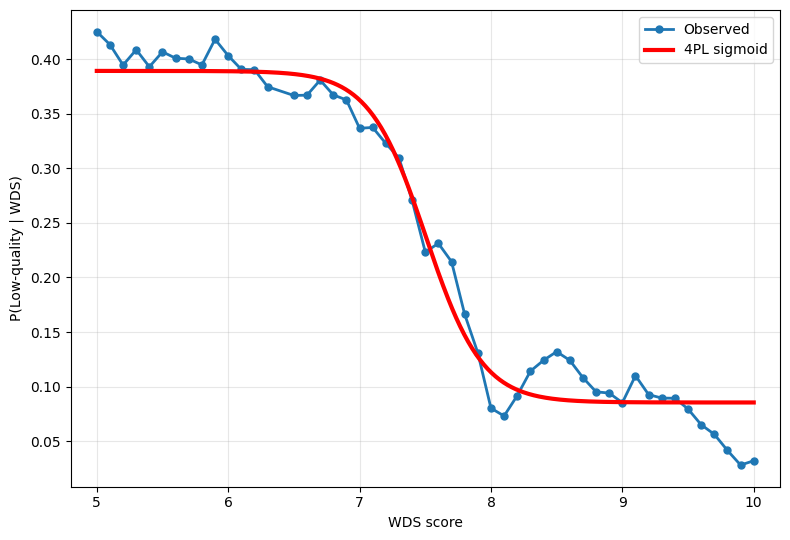

In [ ]:
#With matplotlib for paper
import matplotlib.pyplot as plt
import numpy as np

# Smooth curve
xfit = np.linspace(x.min(), x.max(), 500)
yfit_4pl = four_pl(xfit, *params)

plt.figure(figsize=(8, 5.5))

# Observed
plt.plot(
    x / 10,
    y,
    "-o",
    label="Observed",
    linewidth=2,
    markersize=5,
)

# 4PL fit
plt.plot(
    xfit / 10,
    yfit_4pl,
    color="red",
    label="4PL sigmoid",
    linewidth=3,
)

# Match Plotly layout
plt.xlim(4.8, 10.2)
plt.xticks(np.arange(5, 11, 1))
plt.xlabel("WDS score")
plt.ylabel("P(Low-quality | WDS)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

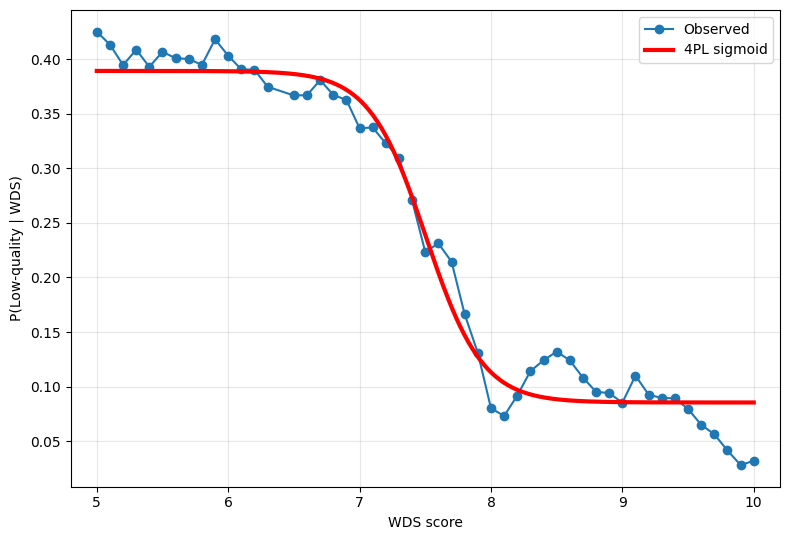

In [14]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5.5))

ax.plot(
    x / 10,
    y,
    "-o",
    label="Observed",
)

ax.plot(
    xfit / 10,
    yfit_4pl,
    color="red",
    linewidth=3,
    label="4PL sigmoid",
)

ax.set_xlim(4.8, 10.2)
ax.set_xticks(np.arange(5, 11, 1))

ax.set_xlabel("WDS score")
ax.set_ylabel("P(Low-quality | WDS)")

ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()
fig.savefig("4pl_fit_2.png", bbox_inches="tight")

plt.show()